# Evaluación del modelo de clasificación

Este notebook documenta la evaluación detallada del modelo optimizado de clasificación de coberturas.

El proceso incluye:

- carga del split estratificado;
- carga del modelo optimizado;
- evaluación sobre el conjunto de prueba;
- generación de métricas globales;
- matriz de confusión;
- reporte de clasificación;
- importancia por permutación.

La evaluación se realiza sobre el modelo optimizado generado en `05_entrenamiento_modelos.ipynb`.


In [1]:
from pathlib import Path
import sys

import pandas as pd

In [2]:
BASE_DIR = Path.cwd()

while not (BASE_DIR / "src").exists() and BASE_DIR != BASE_DIR.parent:
    BASE_DIR = BASE_DIR.parent

sys.path.append(str(BASE_DIR))

print("BASE_DIR detectado:")
print(BASE_DIR)

BASE_DIR detectado:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml


## Importación de funciones auxiliares

La carga del split se realiza desde `muestras.py`.

La evaluación del modelo, matriz de confusión, reporte de clasificación e importancia por permutación se ejecutan desde `evaluacion.py`.


In [3]:
from src.clasificacion_coberturas.muestras import cargar_split_clasificacion

from src.clasificacion_coberturas.evaluacion import (
    cargar_modelo,
    obtener_mapa_clases_desde_puntos,
    pipeline_evaluacion_clasificacion
)

## Configuración de rutas

Se definen las rutas del split, modelo optimizado y carpetas de salida.

El modelo evaluado corresponde al modelo optimizado mediante búsqueda de hiperparámetros.


In [4]:
# ============================================================
# CONFIGURACIÓN GENERAL
# ============================================================

year = 2018

ruta_split = (
    BASE_DIR
    / "data"
    / "interim"
    / "clasificacion_coberturas"
    / "splits"
    / f"split_clasificacion_{year}.joblib"
)

ruta_modelo = (
    BASE_DIR
    / "models"
    / "clasificacion_coberturas"
    / "modelo_clasificacion_tuning.joblib"
)

carpeta_tablas = (
    BASE_DIR
    / "outputs"
    / "tables"
    / "clasificacion_coberturas"
)

carpeta_figuras = (
    BASE_DIR
    / "outputs"
    / "figures"
    / "clasificacion_coberturas"
)

print("Split:")
print(ruta_split)

print("\nModelo optimizado:")
print(ruta_modelo)

print("\nCarpeta de tablas:")
print(carpeta_tablas)

print("\nCarpeta de figuras:")
print(carpeta_figuras)

Split:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\data\interim\clasificacion_coberturas\splits\split_clasificacion_2018.joblib

Modelo optimizado:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\models\clasificacion_coberturas\modelo_clasificacion_tuning.joblib

Carpeta de tablas:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\outputs\tables\clasificacion_coberturas

Carpeta de figuras:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\outputs\figures\clasificacion_coberturas


## Carga del split y del modelo optimizado

Se cargan los datos de prueba y los metadatos del flujo.

Aunque la tabla de comparación pueda mostrar diferencias entre modelo base y modelo optimizado, esta etapa evalúa el modelo optimizado, ya que es el modelo definido para la fase de clasificación espacial.


In [5]:
split_data = cargar_split_clasificacion(ruta_split)

X_test = split_data["X_test"]
y_test = split_data["y_test"]
variables_modelo = split_data["variables_modelo"]
ruta_puntos = Path(split_data["ruta_puntos"])
columna_clase = split_data["columna_clase"]
columna_clase_nombre = split_data["columna_clase_nombre"]
random_state = split_data["random_state"]

modelo = cargar_modelo(ruta_modelo)

print("Split y modelo cargados correctamente.")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("Número de variables:", len(variables_modelo))

Split y modelo cargados correctamente.
X_test: (60, 22)
y_test: (60,)
Número de variables: 22


## Mapa de clases

Se construye un diccionario entre códigos numéricos de clase y etiquetas descriptivas a partir de la capa de puntos de entrenamiento.


In [6]:
mapa_clases = obtener_mapa_clases_desde_puntos(
    ruta_puntos=ruta_puntos,
    columna_clase=columna_clase,
    columna_clase_nombre=columna_clase_nombre
)

mapa_clases

{2.0: 'BOSQUES Y AREAS SEMINATURALES',
 3.0: 'SUPERFICIES DE AGUA',
 5.0: 'TERRITORIOS ARTIFICIALIZADOS'}

## Evaluación del modelo

Se calculan las métricas globales, matriz de confusión, reporte de clasificación e importancia por permutación.

La importancia por permutación mide la pérdida de desempeño al permutar cada variable, por lo que ayuda a identificar variables relevantes para el modelo final.


Tabla guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\outputs\tables\clasificacion_coberturas\metricas_modelo_final.csv
Tabla guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\outputs\tables\clasificacion_coberturas\classification_report.csv
Tabla guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\outputs\tables\clasificacion_coberturas\matriz_confusion.csv
Figura guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\outputs\figures\clasificacion_coberturas\matriz_confusion.png


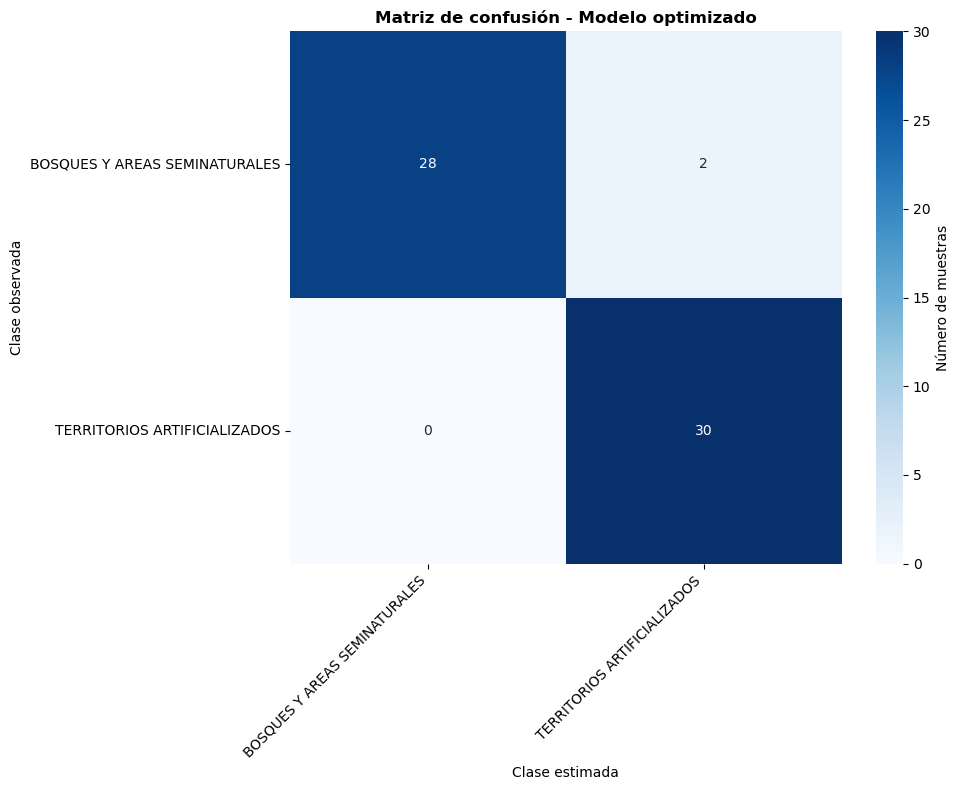

Tabla guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\outputs\tables\clasificacion_coberturas\importancia_permutacion.csv
Figura guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\outputs\figures\clasificacion_coberturas\importancia_permutacion.png


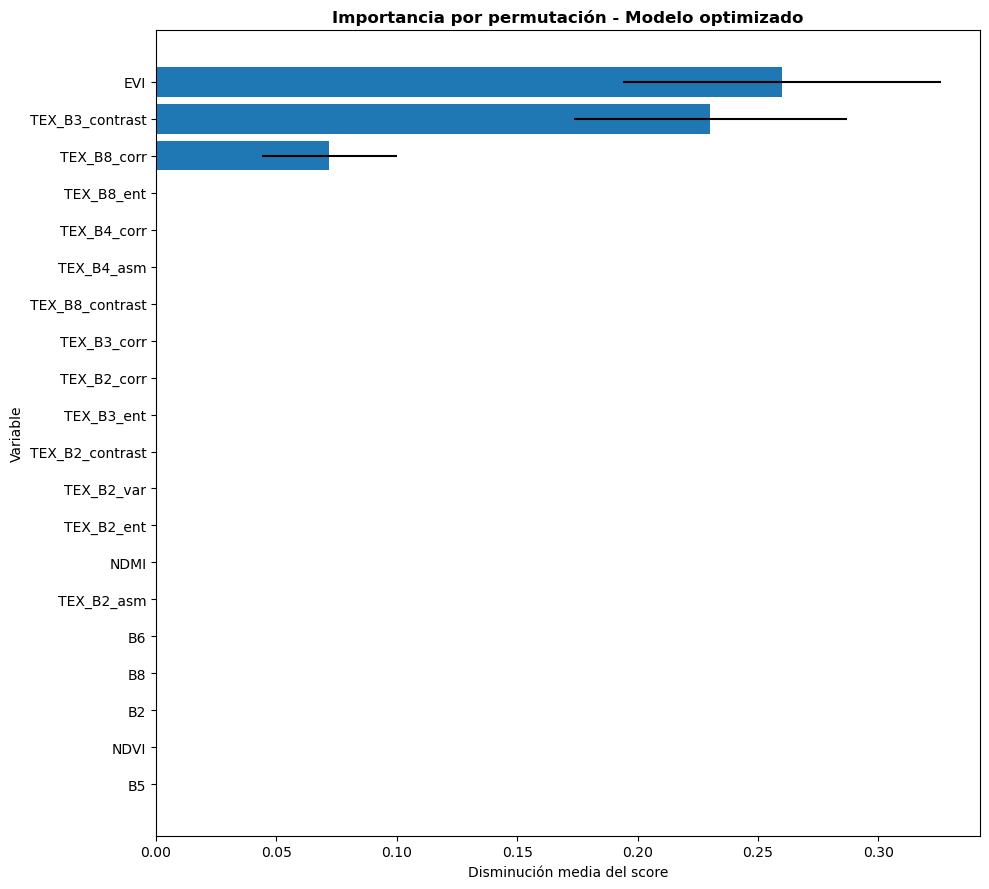

Evaluación completada.


In [7]:
resultados_evaluacion = pipeline_evaluacion_clasificacion(
    modelo=modelo,
    X_test=X_test,
    y_test=y_test,
    variables_modelo=variables_modelo,
    carpeta_tablas=carpeta_tablas,
    carpeta_figuras=carpeta_figuras,
    mapa_clases=mapa_clases,
    scoring_importancia="f1_macro",
    n_repeats_importancia=10,
    random_state=random_state,
    n_jobs=-1
)

df_metricas = resultados_evaluacion["df_metricas"]
df_reporte = resultados_evaluacion["df_reporte"]
df_importancia = resultados_evaluacion["df_importancia"]

print("Evaluación completada.")

## Métricas globales

Se presentan las métricas globales del modelo optimizado sobre el conjunto de prueba.


In [8]:
display(df_metricas)

,accuracy,precision_macro,recall_macro,f1_macro
0,0.966667,0.96875,0.966667,0.96663


## Reporte de clasificación

Se presenta el reporte de precisión, recall y F1-score por clase.


In [9]:
display(df_reporte)

,precision,recall,f1-score,support
2.0,1.000000,0.933333,0.965517,30.000000
5.0,0.937500,1.000000,0.967742,30.000000
accuracy,0.966667,0.966667,0.966667,0.966667
macro avg,0.968750,0.966667,0.966630,60.000000
weighted avg,0.968750,0.966667,0.966630,60.000000


## Importancia por permutación

Se presenta la tabla de importancia por permutación generada para el modelo optimizado.


In [10]:
display(df_importancia.head(20))

,variable,importancia_media,importancia_std
0,EVI,0.260034,0.065933
1,TEX_B3_contrast,0.230208,0.056637
2,TEX_B8_corr,0.071997,0.028166
3,B5,0.000000,0.000000
4,B8,0.000000,0.000000
5,B2,0.000000,0.000000
6,NDVI,0.000000,0.000000
7,B6,0.000000,0.000000
8,TEX_B2_ent,0.000000,0.000000
9,NDMI,0.000000,0.000000


## Producto de esta etapa

Al finalizar este notebook se generan:

- métricas globales del modelo final;
- matriz de confusión;
- reporte de clasificación;
- importancia por permutación;
- figuras de evaluación.

Las tablas se guardan en:

`outputs/tables/clasificacion_coberturas/`

Las figuras se guardan en:

`outputs/figures/clasificacion_coberturas/`

## Siguiente etapa del flujo

Una vez evaluado el modelo optimizado, el siguiente paso consiste en aplicarlo espacialmente sobre el raster reducido para generar el mapa clasificado de coberturas.

Esta fase se documenta en:

`07_clasificacion_espacial.ipynb`
